In [42]:
#Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering

In [43]:
#Import dataset

url = 'https://github.com/FourthRevGitHub/CAM_DS_Public-Data-Sets/raw/main/Course%201/Week%206/CUSTOMERS_CLEAN.zip'

data = pd.read_csv(url)
data.head()

,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,OrderTypeLabel,CustomerCountryLabel,Customer_BirthDate,Customer_Group,Customer_Type,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID
0,3,Leinster,Oceania,6437,Western Australia,01JAN2012,07JAN2012,$28.50,$9.10,.,Internet Sale,Australia,08MAY1978,Internet/Catalog Customers,Internet/Catalog Customers,1230000033,$1.20,6,99,8818
1,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,$113.40,$56.90,.,Internet Sale,Australia,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,($0.40),3,99,47793
2,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,$41.00,$18.50,.,Internet Sale,Australia,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,$4.00,3,99,47793
3,1,Northbridge,Oceania,2063,New South Wales,01JAN2012,03JAN2012,$35.20,$29.60,.,Internet Sale,Australia,22JUN1997,Orion Club Gold members,Orion Club Gold members high activity,1230000268,$5.60,2,0,71727
4,1,Montréal,North America,NaN,Quebec,01JAN2012,04JAN2012,$24.70,$23.60,.,Internet Sale,Canada,28JAN1978,Orion Club Gold members,Orion Club Gold members medium activity,1230000487,$1.10,3,99,74503


## 1. Data Quality Checks



In [44]:
#Null Values

data.isnull().sum()

,0
Quantity,0
City,135
Continent,0
Postal_Code,3716
State_Province,117192
Order_Date,0
Delivery_Date,0
Total Revenue,0
Unit Cost,0
Discount,0


In [45]:
#Fill state_province and Postal_code with unknown

data['Postal_Code'] = data['Postal_Code'].fillna('Unknown')
data['State_Province'] = data['State_Province'].fillna('Unknown')

In [46]:
#Fill City with mode of postal code or state province matches

data['City'] = data.groupby('Postal_Code')['City'].transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x)
data['City'] = data.groupby('State_Province')['City'].transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x)
data['City'].fillna('Unknown')
print('Null values after filling City:')
data.isna().sum()

Null values after filling City:


,0
Quantity,0
City,0
Continent,0
Postal_Code,0
State_Province,0
Order_Date,0
Delivery_Date,0
Total Revenue,0
Unit Cost,0
Discount,0


In [47]:
#Check for duplicates

data.duplicated().sum()

np.int64(21)

In [48]:
#Remove Duplicates

data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

**Observations**

- Dataset had missing values in three columns
- Dataset had 21 duplicate rows
- Missing values in Postal_Code and State_Province were filled with unknown placeholders due to the amount of missing values in state province, and the amount of possible unique values in Postal_code
- Missing values in City were filled with predicted values based on information gathered from available values in State Province, and Postal code.

## 2. Feature engineering

For this project we will create new features for frequency, recency, CLV, average unit cost, and customer age

In [49]:
#Convert currency strings to numeric

def currency_float(values):
  # Handle negative numbers represented with parentheses
  s_values = str(values).replace('$', '').replace(',', '')
  if s_values.startswith('(') and s_values.endswith(')'):
    s_values = '-' + s_values[1:-1]
  return float(s_values)

#Apply function to currency columns

data['Unit Cost'] = data['Unit Cost'].apply(currency_float)
data['Total Revenue'] = data['Total Revenue'].apply(currency_float)
data['Profit'] = data['Profit'].apply(currency_float)

#Convert time columns to better format

data['Order_Date_dt'] = pd.to_datetime(data['Order_Date'])
data['Delivery_Date_dt'] = pd.to_datetime(data['Delivery_Date'])
data['Birth_Date_dt'] = pd.to_datetime(data['Customer_BirthDate'])

print('Types after conversion:')
print(data[['Total Revenue','Unit Cost','Delivery_Date_dt']].dtypes)

/tmp/ipykernel_10963/301007869.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Order_Date_dt'] = pd.to_datetime(data['Order_Date'])
/tmp/ipykernel_10963/301007869.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Delivery_Date_dt'] = pd.to_datetime(data['Delivery_Date'])
/tmp/ipykernel_10963/301007869.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Birth_Date_dt'] = pd.to_datetime(data['Customer_BirthDate'])


Types after conversion:
Total Revenue              float64
Unit Cost                  float64
Delivery_Date_dt    datetime64[ns]
dtype: object


In [50]:
#Create Recency Column

data['Recency'] = (pd.to_datetime('today') - (data['Delivery_Date_dt'])).dt.days

#Frequency Column

data['Frequency'] = data.groupby('Customer ID')['Order ID'].transform('count')

#CLV

data['CLV'] = data['Total Revenue']

#Average Unit Cost

data['Avg_Unit_Cost'] = data.groupby('Customer ID')['Unit Cost'].transform('mean')

#Customer Age
today = pd.Timestamp('now')
data['Age'] = (today - data['Birth_Date_dt']).dt.days // 365

#Show table

data[['Customer ID','Order ID','Frequency','Recency','CLV','Avg_Unit_Cost','Age']].head(8)

,Customer ID,Order ID,Frequency,Recency,CLV,Avg_Unit_Cost,Age
0,8818,1230000033,31,5204,28.5,60.206452,47
1,47793,1230000204,20,5207,113.4,66.280000,47
2,47793,1230000204,20,5207,41.0,66.280000,47
3,71727,1230000268,20,5208,35.2,74.775000,28
4,74503,1230000487,6,5207,24.7,74.300000,48
5,8610,1230000494,3,5204,136.1,183.866667,62
6,19278,1230000689,12,5206,358.6,118.333333,29
7,28861,1230000871,31,5207,1.7,72.990323,31


#### 2.1 Data Aggregation

- We will convert the dataset to one row per customer

In [51]:
df_agg = data.groupby('Customer ID').agg(
    Frequency=('Order ID', 'count'),
    Recency=('Delivery_Date_dt', lambda x: (today - x.max()).days),
    CLV=('CLV', 'sum'),
    Avg_Unit_Cost=('Avg_Unit_Cost', 'mean'),
    Age=('Age', 'first'),
).reset_index()

print(f'Number of customers:{df_agg.shape[0]}')
df_agg.head()

Number of customers:68300


,Customer ID,Frequency,Recency,CLV,Avg_Unit_Cost,Age
0,1,35,3402,4322.70,89.622857,72
1,3,20,3504,2821.00,90.505000,42
2,4,9,4493,782.67,37.195556,42
3,5,19,3390,2810.98,107.947368,37
4,6,15,3575,1604.58,52.526667,67


## 3. Exploratory Data Analysis

In [52]:
# Set features

features = ['Frequency','Recency','CLV','Avg_Unit_Cost','Age']

In [53]:
#Descriptive statistics

df_agg[features].describe()

,Frequency,Recency,CLV,Avg_Unit_Cost,Age
count,68300.000000,68300.000000,68300.000000,68300.000000,68300.000000
mean,13.933353,3751.399971,1950.148420,78.895675,52.416442
std,11.328807,414.289931,1719.916365,38.005259,17.493276
min,1.000000,3365.000000,0.630000,0.500000,28.000000
25%,6.000000,3429.000000,696.000000,57.579792,37.000000
50%,11.000000,3573.000000,1497.400000,73.450000,52.000000
75%,19.000000,3923.000000,2709.845000,92.515260,67.000000
max,121.000000,5209.000000,18860.960000,1463.500000,83.000000


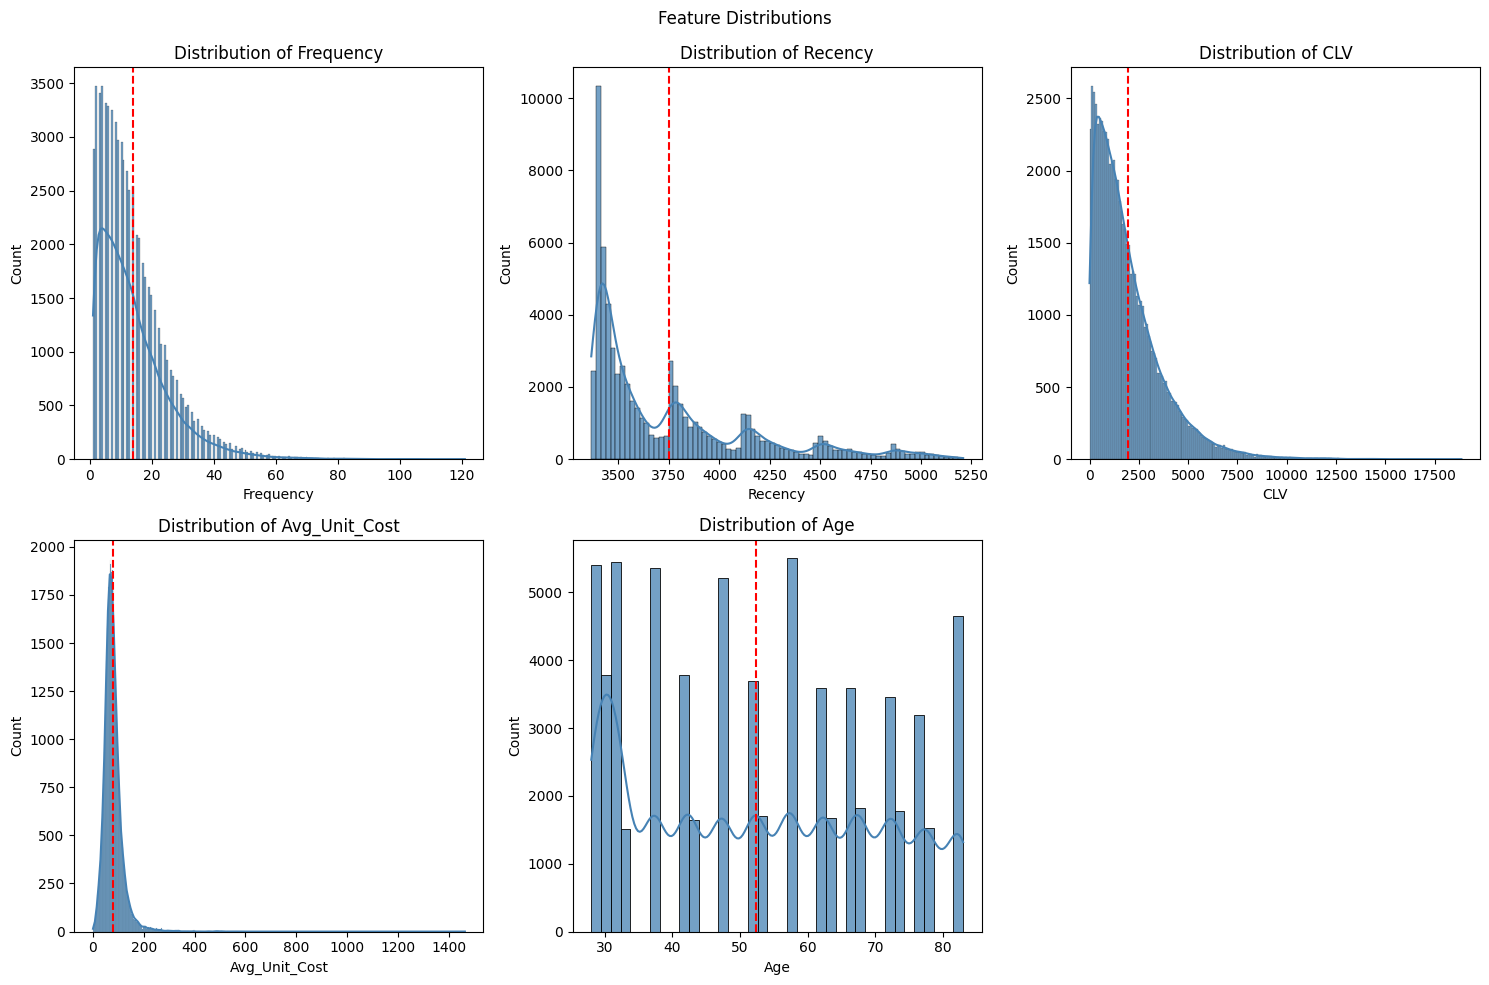

In [54]:
#Histogram plots

fig,axes = plt.subplots(2,3,figsize=(15,10))

for i, col in enumerate(features):
  ax = axes[i // 3][i % 3]
  sns.histplot(data=df_agg,kde=True,x=col,ax=ax,color='steelblue',alpha=0.75)
  ax.axvline(df_agg[col].mean(), color='red', linestyle='dashed', linewidth=1.5, label='Mean')
  ax.set_title(f'Distribution of {col}')

axes[1][2].set_visible(False)
plt.tight_layout(rect=[0,0,1,0.96])
plt.suptitle('Feature Distributions')
plt.savefig('histogram.png')

plt.show()

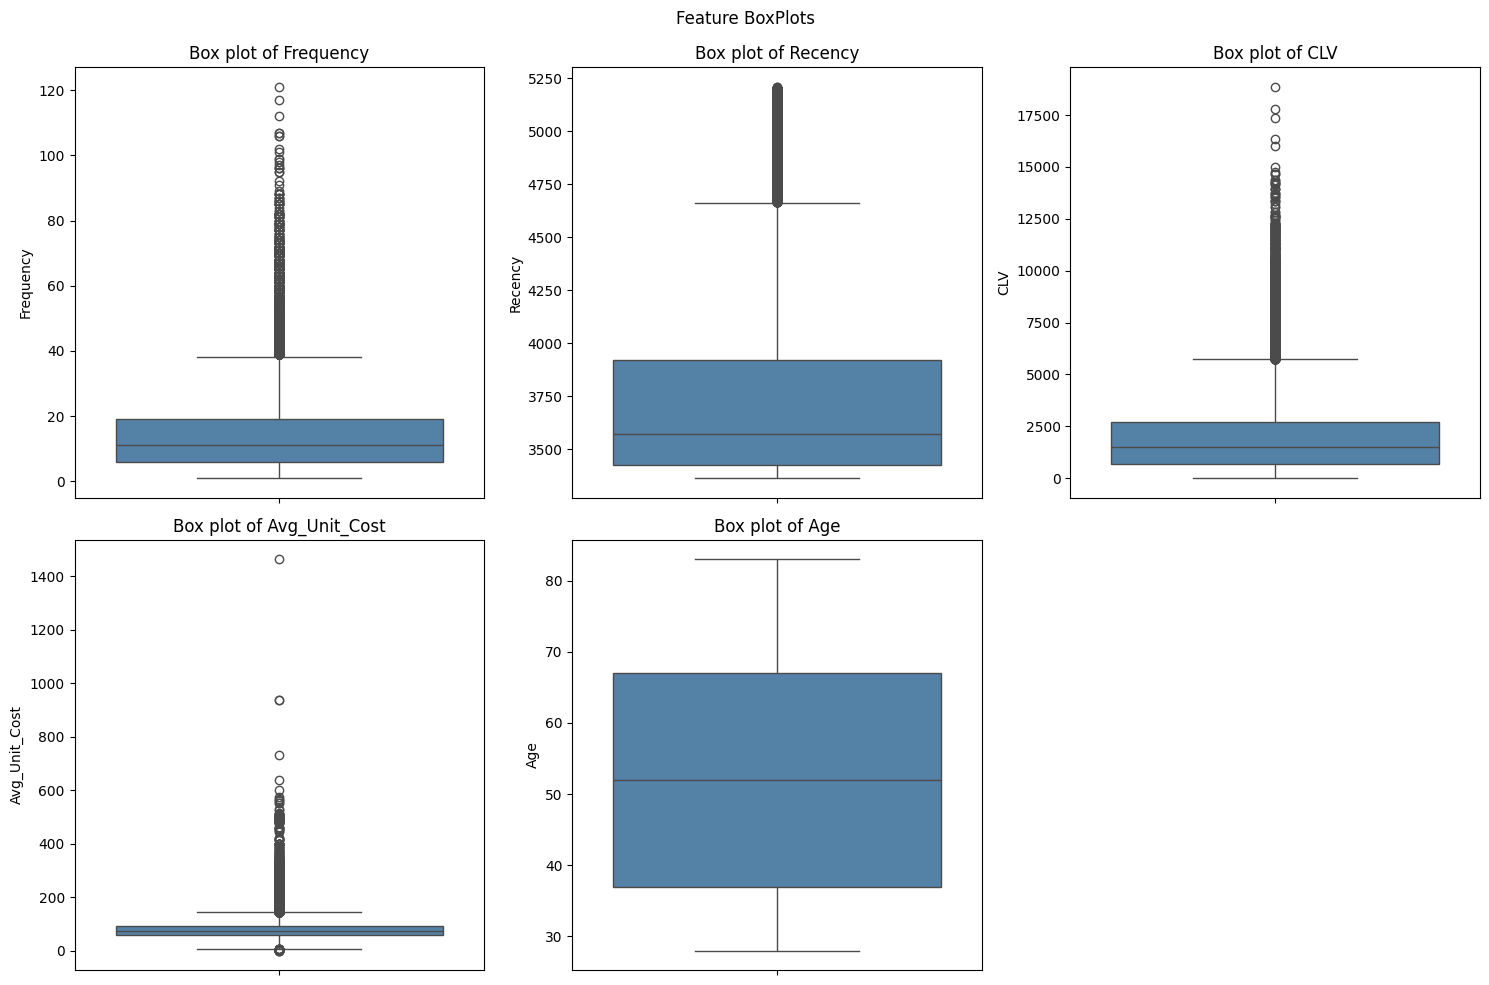

In [55]:
# Boxplot for outlier detection

fig,axes = plt.subplots(2,3,figsize=(15,10))

for i, col in enumerate(features):
  ax = axes[i // 3][i % 3]
  sns.boxplot(y=df_agg[col], ax=ax,color='steelblue',orient='v')
  ax.set_title(f'Box plot of {col}')

axes[1][2].set_visible(False)
plt.tight_layout(rect=[0,0,1,0.96])
plt.suptitle('Feature BoxPlots')
plt.savefig('boxplot.png')
plt.show()

#### Data Distribution

**Observations**

- Frequency: Data is right skewed with most customers making fewer purchases, but a large tail of high-frequency buyers
- Recency: Data is multi-modal, with distinct peaks at 5 seperate times (maybe linked to marketing campaigns or offers)
- CLV: Data is heavily right skewed, with majority of customers contributing lower revenue and a small number contributing disproportionately high revenue.
- Avg_unit_cost: Slightly right skewed, most customers buy lower cost products, with a long tail of high-cost customers and a max value of 1463 (1384.6 greater than the mean)
- Age: Approximately normally distributed. Age range between 28 and 83, with all groups represented fairly evenly. Slightly greater values between 28-34

#### Outliers

- Large number of outliers are present in all four features other than age.
- Remove extreme ouliers using 3*iqr method in data preprocessing

## 3. Data Preprocessing

In [56]:
# Flip Recency so high value = more recent to match rest of feature scales

df_clean = df_agg.copy()
df_clean['Recency'] = df_agg['Recency'].max() - df_agg['Recency']
features = ['Frequency', 'Recency', 'CLV', 'Avg_Unit_Cost', 'Age']

# Outlier Removal
print("Customers before outlier removal:", len(df_clean))

for col in features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR

    outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(f"{col}: removed {outliers} outliers (bounds: {lower:.1f} to {upper:.1f})")

    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

print("\nCustomers after outlier removal:", len(df_clean))
print(f"Removed {len(df_agg) - len(df_clean)} customers in total ({(len(df_agg) - len(df_clean)) / len(df_agg) * 100:.1f}%)")

Customers before outlier removal: 68300
Frequency: removed 412 outliers (bounds: -33.0 to 58.0)
Recency: removed 0 outliers (bounds: -205.0 to 3267.0)
CLV: removed 193 outliers (bounds: -5278.8 to 8651.4)
Avg_Unit_Cost: removed 899 outliers (bounds: -47.8 to 197.7)
Age: removed 0 outliers (bounds: -53.0 to 157.0)

Customers after outlier removal: 66796
Removed 1504 customers in total (2.2%)


- Recency has been inverted to match the rest of the data. A higher recency number now means more recent purchase

#### 3.1 Standardising data

In [57]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean[features])

print('Shape of scaled data:')
print(df_scaled.shape)
print(f'Mean of data{df_scaled.mean(axis=0)}')
print(f'Std of data{df_scaled.std(axis=0)}')

Shape of scaled data:
(66796, 5)
Mean of data[ 8.45415653e-17  1.47754934e-16 -3.69121398e-17  8.78657853e-17
 -8.70147850e-17]
Std of data[1. 1. 1. 1. 1.]


## 4. Selecting Optimal Cluster Number

#### 4.1 Elbow Method

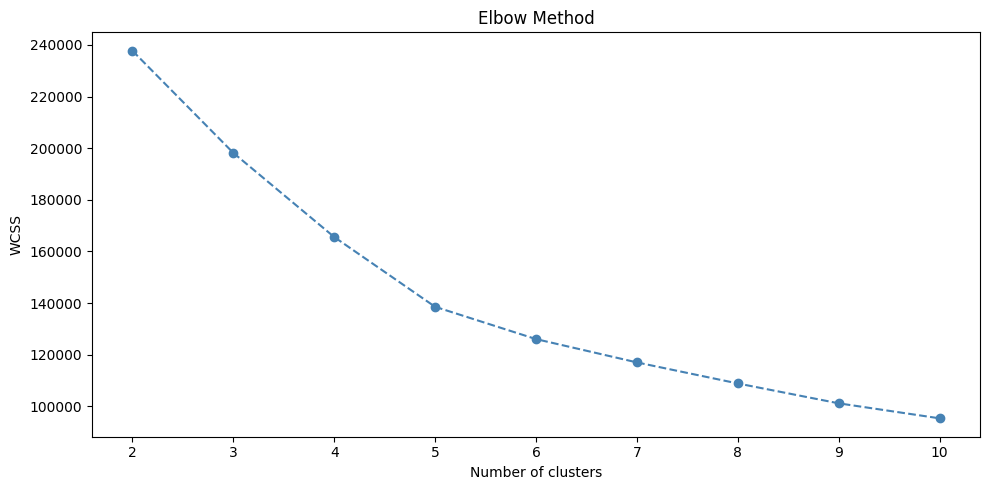

In [58]:
wcss = []
k_range = range(2,11)

#Fit kmeans for all values through 2-10

for k in k_range:
  km = KMeans(n_clusters=k,random_state=42)
  km.fit(df_scaled)
  wcss.append(km.inertia_)

#Create plot for visualising elbow

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(list(k_range),wcss,marker='o',linestyle='--',color='steelblue')
ax.set_title('Elbow Method')
ax.set_xlabel('Number of clusters')
ax.set_ylabel('WCSS')
plt.tight_layout()
plt.savefig('elbow.png')
plt.show()

**Observation**

- The WCSS curve drops steeply from k=2 to k=5, then begins to flatten noticeably from k=5 onwards, with much smaller reductions in WCSS for each additional cluster. This suggests k=5 as the point of diminishing returns.
- Silhoutte score to confirm  

#### 4.2 Silhouette Score

Variance explained by 2 PCs: 65.6%
For n_clusters = 2, average silhouette_score: 0.2580
For n_clusters = 3, average silhouette_score: 0.2393
For n_clusters = 4, average silhouette_score: 0.2411
For n_clusters = 5, average silhouette_score: 0.2541
For n_clusters = 6, average silhouette_score: 0.2359
For n_clusters = 7, average silhouette_score: 0.2240
For n_clusters = 8, average silhouette_score: 0.2254
For n_clusters = 9, average silhouette_score: 0.2266
For n_clusters = 10, average silhouette_score: 0.2234


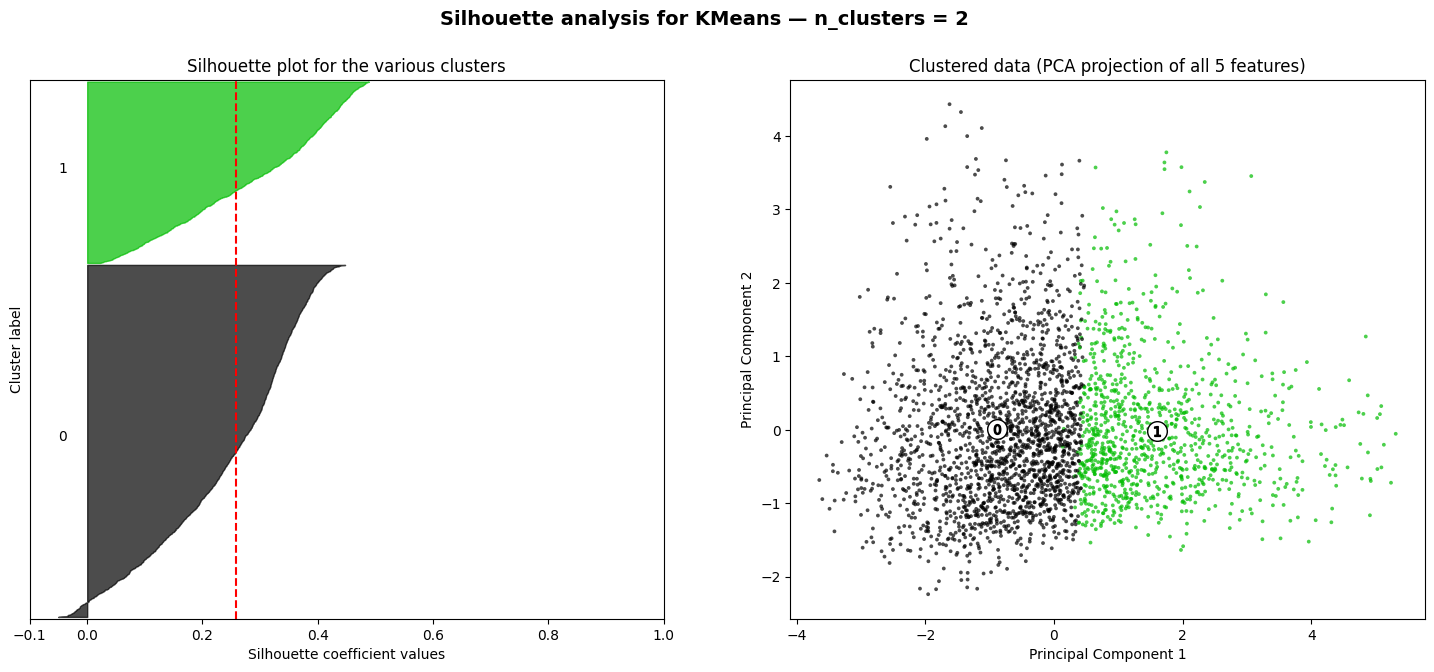

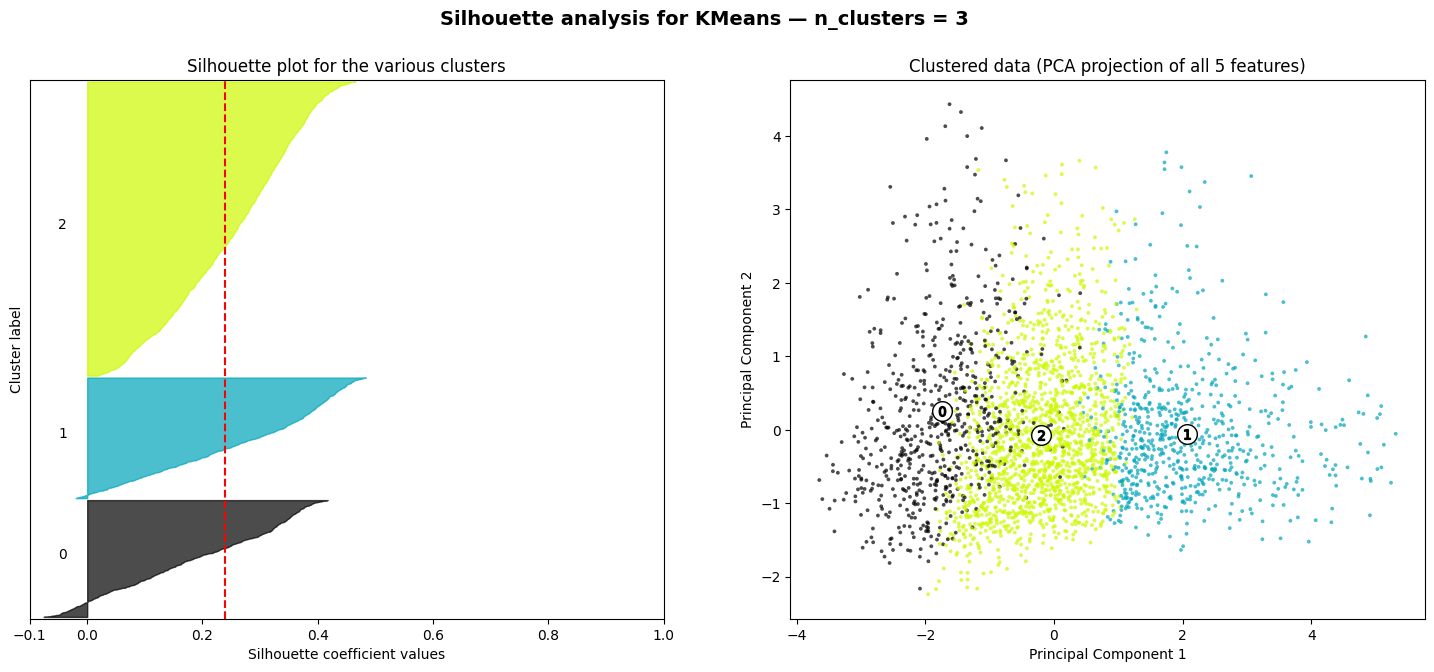

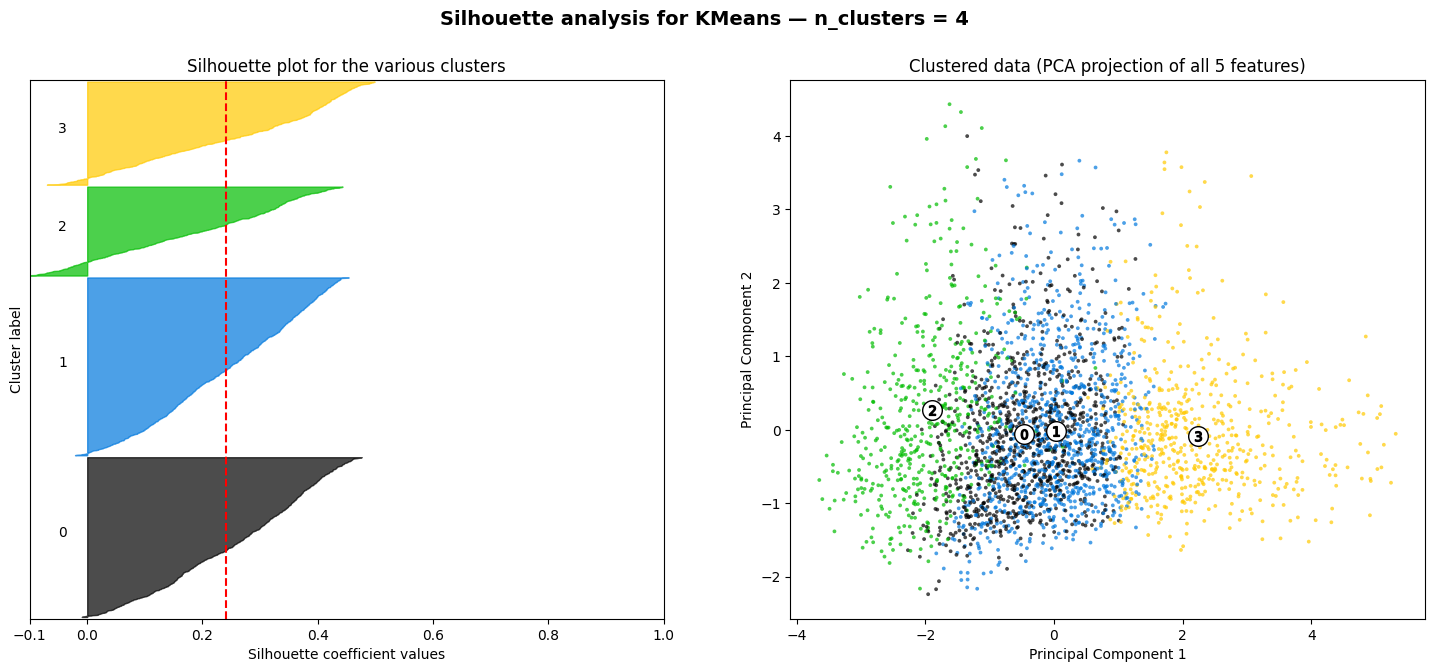

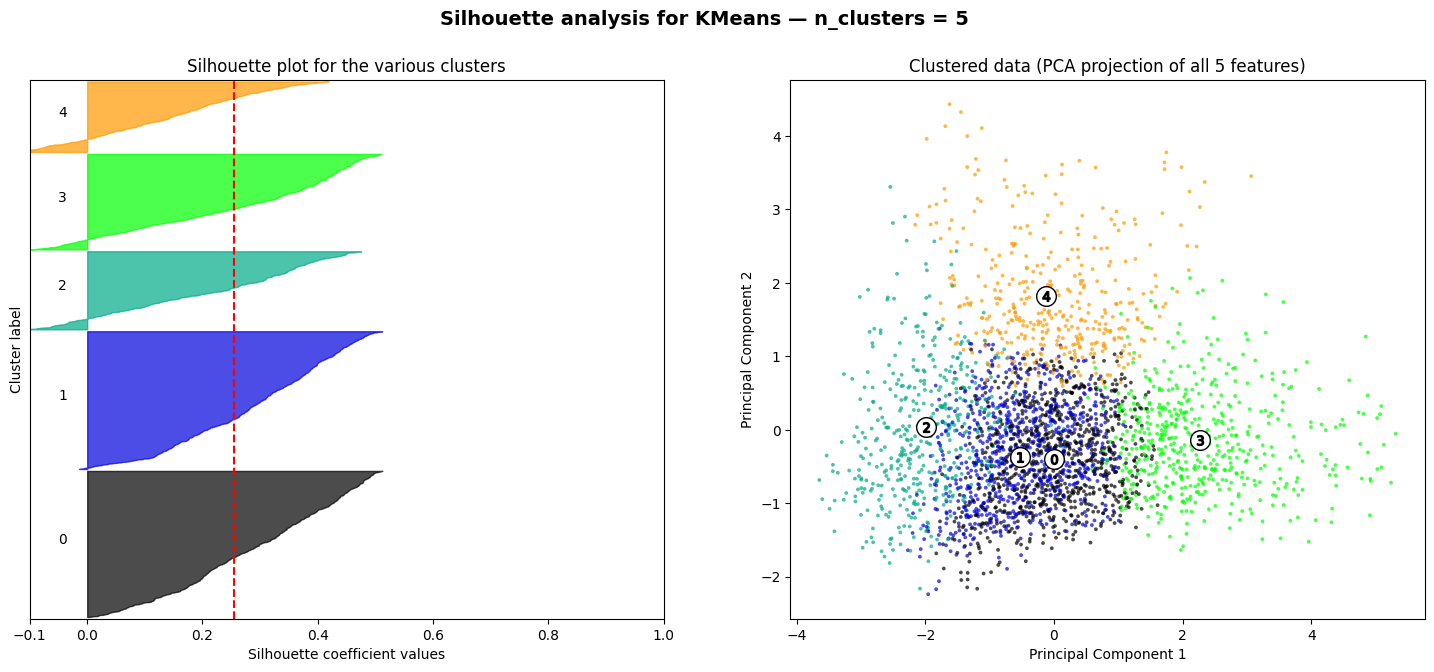

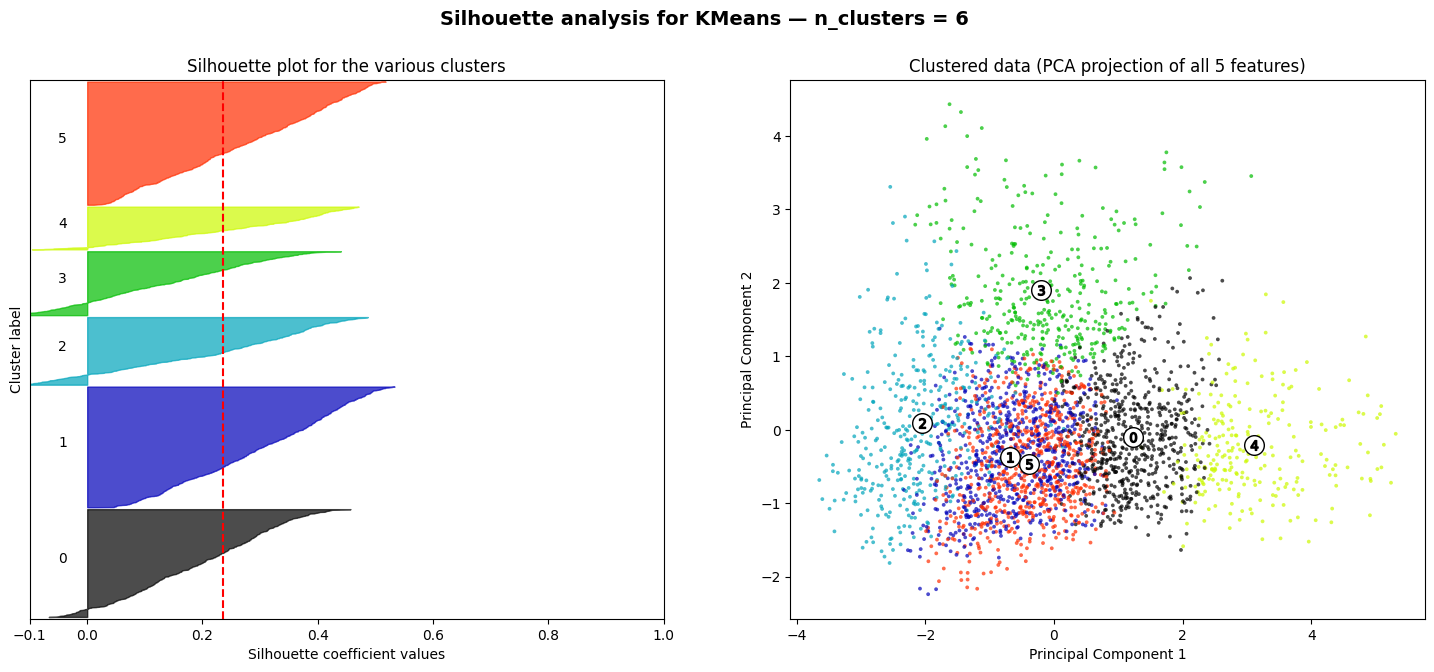

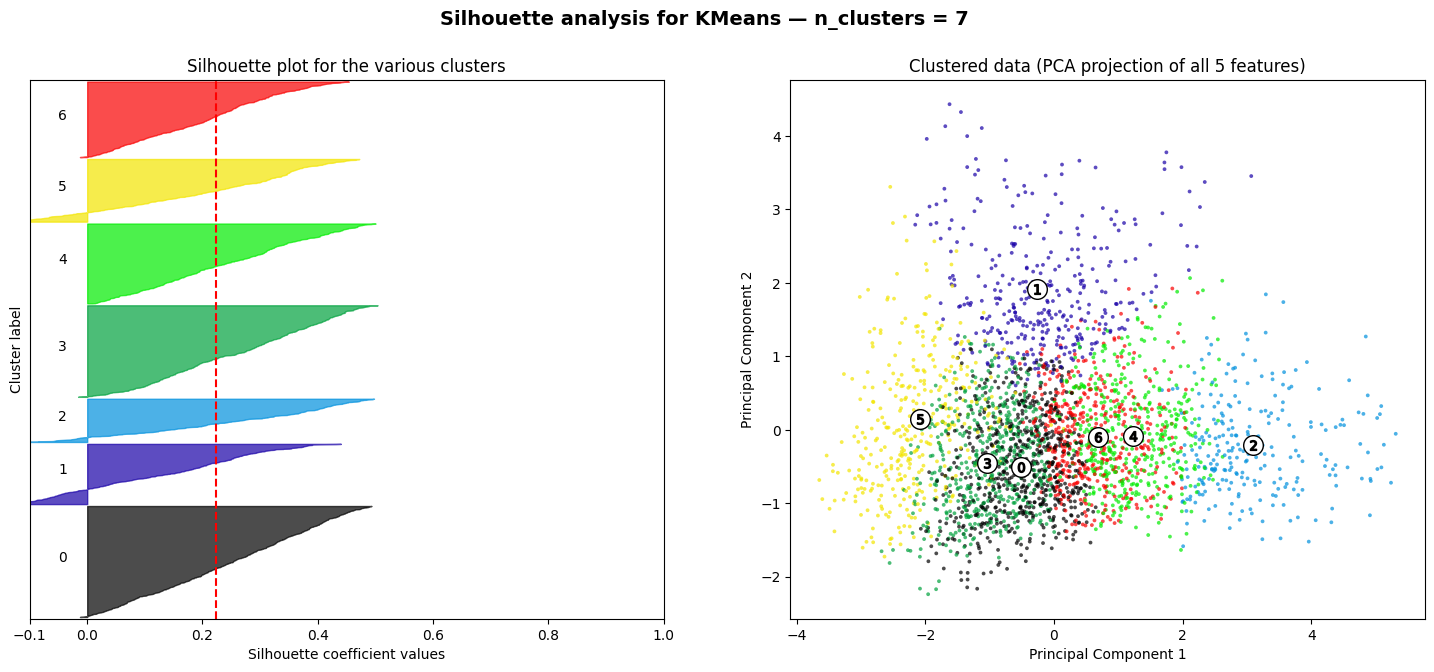

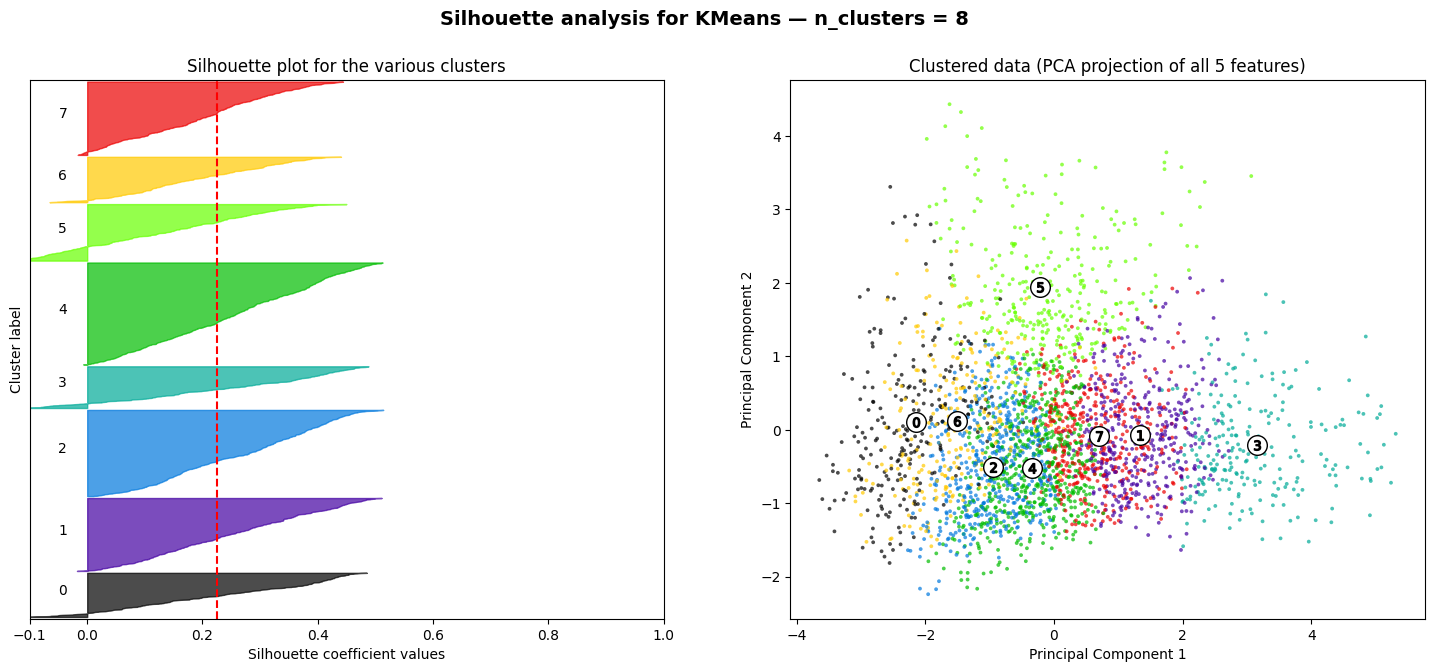

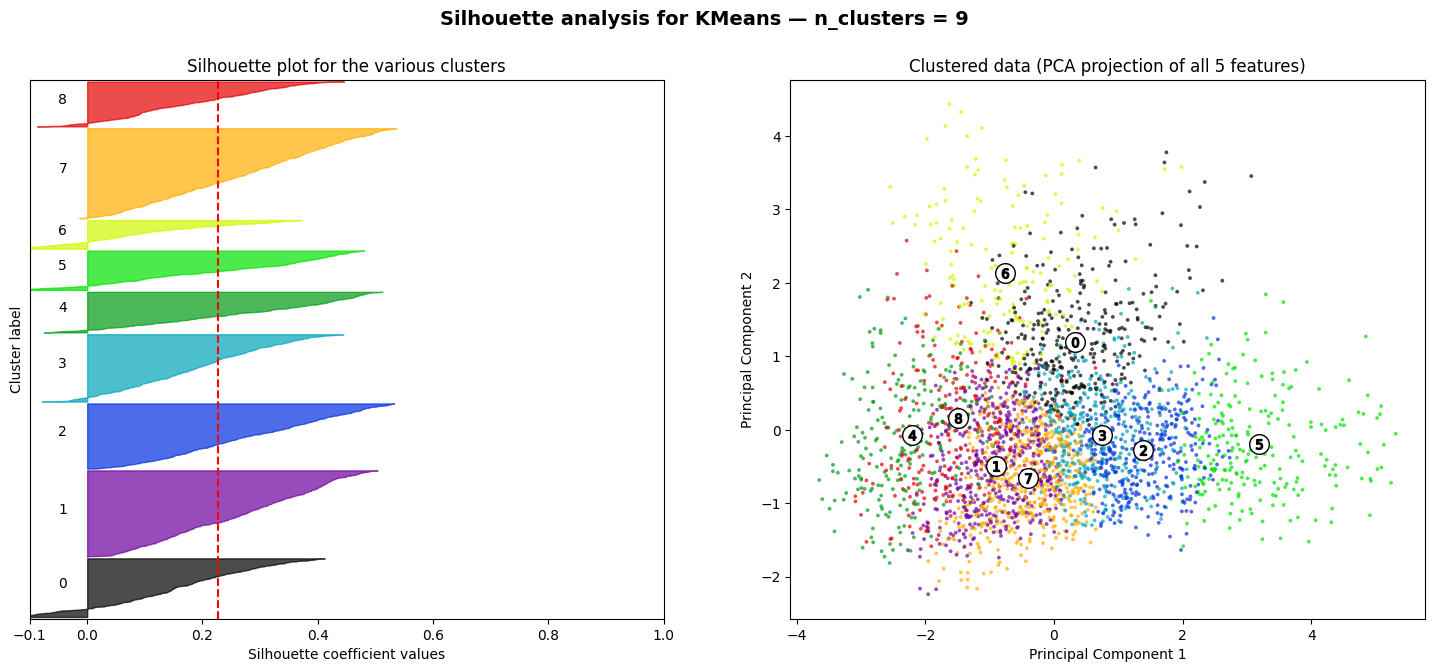

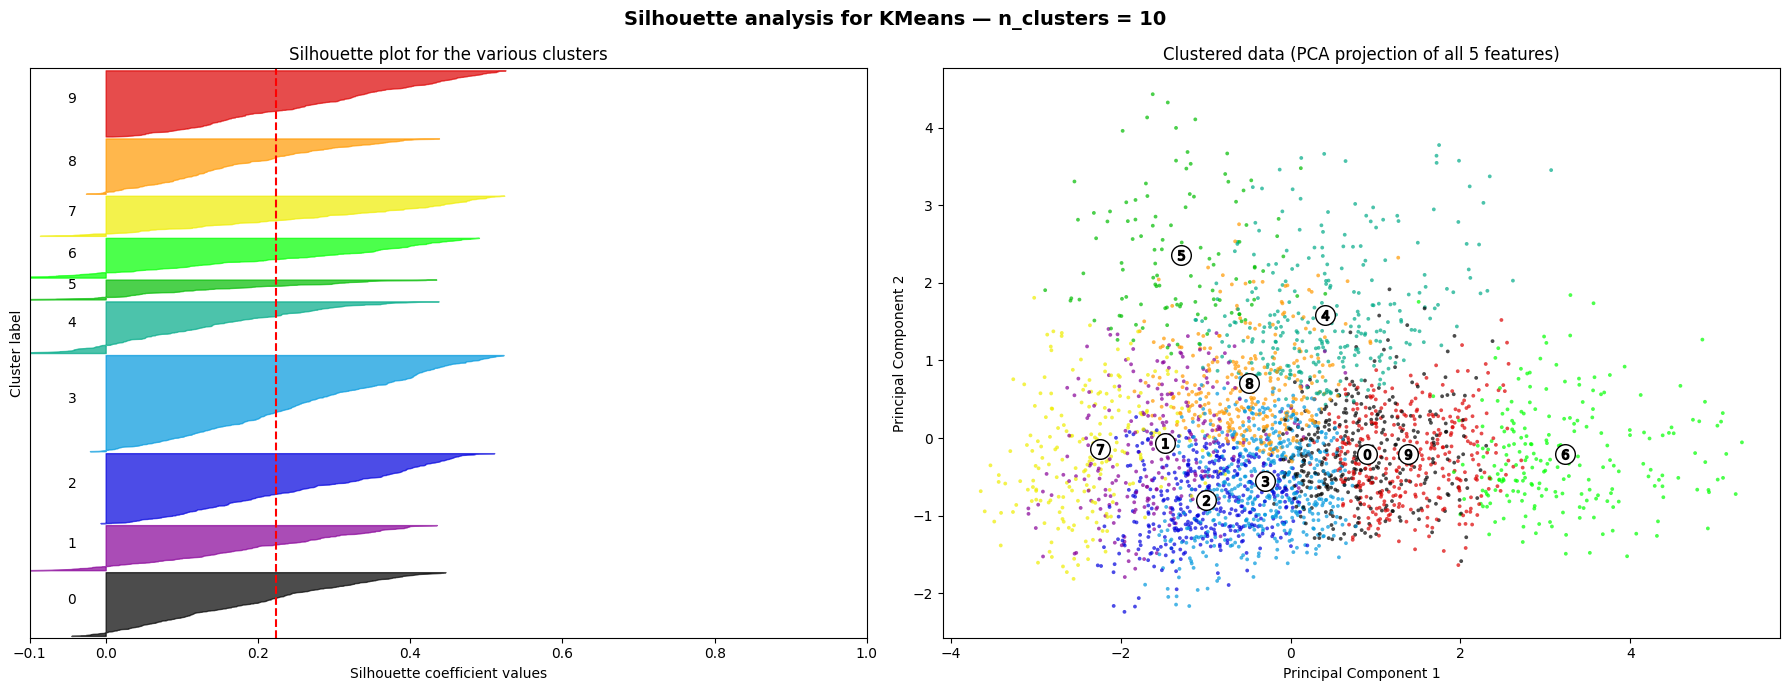

In [59]:
import matplotlib.cm as cm

#PCA for visualisation of clusters

pca = PCA(n_components=2)
df_2d = pca.fit_transform(df_scaled)
print(f"Variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.1%}")

# Sample for silhouette score given  68,300 rows
SAMPLE_SIZE = 3000
np.random.seed(42)
sample_idx = np.random.choice(len(df_scaled), SAMPLE_SIZE, replace=False)
df_scaled_sample = df_scaled[sample_idx]
df_2d_sample = df_2d[sample_idx]

for n_clusters in k_range:
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, SAMPLE_SIZE + (n_clusters + 1) * 10])

    # Fit KMeans on full scaled data
    clusterer = KMeans(n_clusters=n_clusters, random_state=10, n_init=10)
    clusterer.fit(df_scaled)


    cluster_labels_sample = clusterer.predict(df_scaled_sample)

    # Silhouette score on sample
    silhouette_avg = silhouette_score(df_scaled_sample, cluster_labels_sample)
    print(f"For n_clusters = {n_clusters}, average silhouette_score: {silhouette_avg:.4f}")

    # Silhouette values per sample point
    sample_silhouette_values = silhouette_samples(df_scaled_sample, cluster_labels_sample)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels_sample == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.set_title("Silhouette plot for the various clusters")
    ax1.set_xlabel("Silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

Scatter plot using PCA-reduced 2D data (sample only for speed)
    colors = cm.nipy_spectral(cluster_labels_sample.astype(float) / n_clusters)
    ax2.scatter(df_2d_sample[:, 0], df_2d_sample[:, 1],
                marker='.', s=30, lw=0, alpha=0.7, c=colors, edgecolor='k')

    # Project cluster centres into 2D PCA space
    centers_2d = pca.transform(clusterer.cluster_centers_)
    ax2.scatter(centers_2d[:, 0], centers_2d[:, 1],
                marker='o', c="white", alpha=1, s=200, edgecolor='k')
    for i, c in enumerate(centers_2d):
        ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1, s=50, edgecolor='k')

    ax2.set_title("Clustered data (PCA projection of all 5 features)")
    ax2.set_xlabel("Principal Component 1")
    ax2.set_ylabel("Principal Component 2")

    plt.suptitle(f"Silhouette analysis for KMeans — n_clusters = {n_clusters}",
                 fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('silhouette.png')
plt.show()

**Observations**

- The highest silhouette score is k=2 (0.2580) next is at k=5 (0.2541), which is also consistent with the elbow method
- All scores sit in the 0.22–0.27 range, which is relatively low
- Both methods agree — k=5 is the optimal number of clusters. However, the modest silhouette scores suggest the customer segments, while real, are not sharply separated
- PCA = 65.3% - roughly a third of the data structure is invisible in plots. Don't use for interpretation.




## 5. Hierarchical Clustering

Running hierarchical clustering on 3000 sampled customers


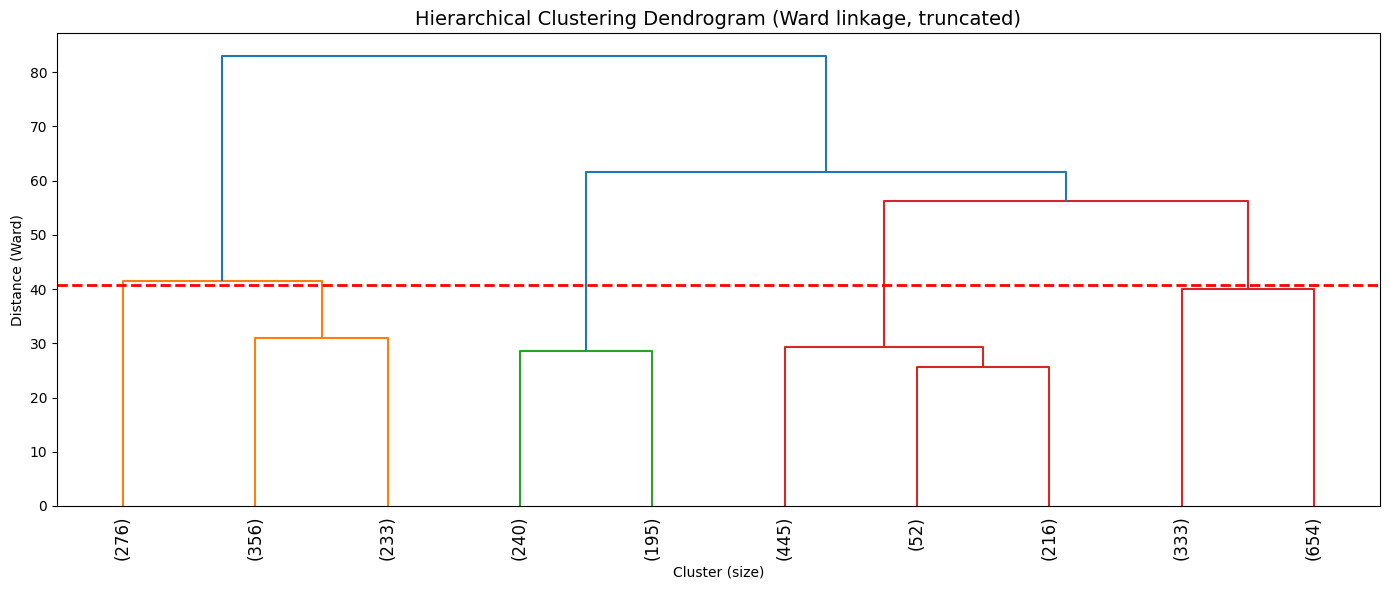

In [60]:
# Sample data with 3000 rows
np.random.seed(42)
hc_sample_idx = np.random.choice(len(df_scaled), 3000, replace=False)
df_hc_sample = df_scaled[hc_sample_idx]

print(f"Running hierarchical clustering on {len(df_hc_sample)} sampled customers")

# Compute Ward linkage matrix
Z = linkage(df_hc_sample, method='ward')

cut = (Z[-5+1, 2] + Z[-5, 2]) / 2



# Plot dendrogram — truncated to last 10 merges to keep it readable
fig, ax = plt.subplots(figsize=(14, 6))

dendrogram(
    Z,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=10,                    # number of merged clusters to display
    leaf_rotation=90,
    leaf_font_size=12,
    ax=ax
)
ax.axhline(y=cut, color='red', linestyle='--', linewidth=2,
           label='Cut → 5 clusters')
ax.set_title('Hierarchical Clustering Dendrogram (Ward linkage, truncated)', fontsize=14)
ax.set_xlabel('Cluster (size)')
ax.set_ylabel('Distance (Ward)')



plt.tight_layout()
plt.savefig('dendrogram.png')
plt.show()

**Overall Observations and Optimal Cluster Number Conclusion**

- All silhouette scores across k=2 to k=10 fall within a narrow range of 0.2225 to 0.2580, indicating the data does not contain strongly separated natural clusters at any value of k — meaning no single choice is statistically dominant.

- The elbow curve shows the rate of WCSS improvement slowing significantly from k=5 onwards, with drops beyond k=5 being roughly half those seen at lower values of k, supporting k=5 as the point of diminishing returns

- Silhouette Scores show k=5 as the highest values after k=2 at 0.2541.

- k=2, whilst statistically the strongest choice, produces clusters that effectively split 66,000 customers into just two broad groups with limited business value.

- The dendrogram does not strongly support k=5 in isolation, with the largest gaps suggesting k=2 and k=3. However, given the absence of statistically dominant clusters at any k, k=5 was selected on the basis of the elbow method, silhouette score, and business interpretability.

- k=5 was selected as the optimal number of clusters

## 6. Apply K-Means Clustering

K-Means is applied with k = 5

In [61]:
df_clean.shape

(66796, 6)

In [62]:
#Run K means
k_optimal = 5

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(df_scaled)

print(df_clean['Cluster'].value_counts().sort_index())




Cluster
0     8387
1    17342
2     9587
3    12800
4    18680
Name: count, dtype: int64


#### 6.1 Cluster Assignment

In [63]:
#Create cluster assignment table

df_clean[['Customer ID', 'Cluster']].rename(columns={'Customer ID': 'Customer_ID'}).head(20)

,Customer_ID,Cluster
0,1,3
1,3,4
2,4,2
3,5,4
4,6,1
5,7,3
6,9,3
7,10,3
8,11,4
9,12,4


#### 6.2 Cluster Statistics

In [64]:
#Statistics for each cluster group



features = ['Frequency', 'Recency', 'CLV', 'Avg_Unit_Cost', 'Age']

cluster_stats = df_clean.groupby('Cluster')[features].mean()
cluster_stats


,Frequency,Recency,CLV,Avg_Unit_Cost,Age
Cluster,,,,,
0,8.102420,1386.605938,1782.941294,128.688811,52.408847
1,10.657479,1598.429651,1276.153858,65.596251,69.461711
2,4.833212,690.434755,549.993637,59.478405,57.269323
3,29.981953,1696.451328,4387.281602,81.910869,48.341250
4,12.208351,1594.159047,1480.659449,67.530239,36.958887


#### 6.3 Cluster Box Plots

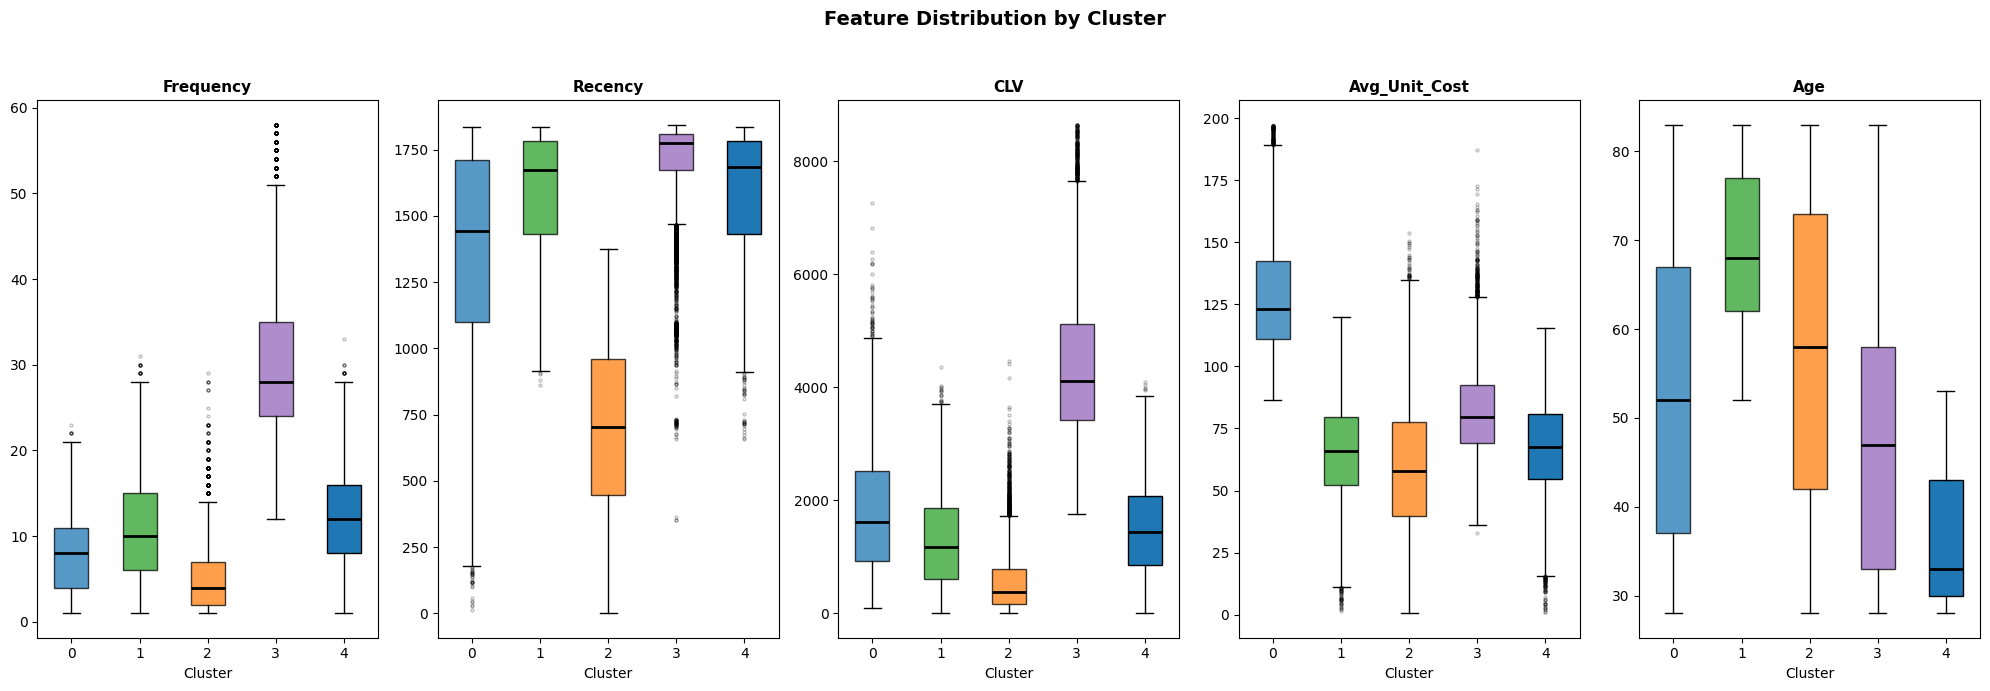

In [65]:
#Box Plots for each clusters

fig, axes = plt.subplots(1, 5, figsize=(20, 7))
colors_c = ['#1f77b4','#2ca02c','#ff7f0e','#9467bd']

for i, col in enumerate(features):
    data = [df_clean.loc[df_clean['Cluster']==c, col].values for c in range(k_optimal)]
    bp = axes[i].boxplot(data, patch_artist=True,
                          medianprops=dict(color='black', linewidth=2),
                          flierprops=dict(markersize=2, alpha=0.25))
    for patch, clr in zip(bp['boxes'], colors_c):
        patch.set_facecolor(clr); patch.set_alpha(0.75)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_xticks(range(1, k_optimal+1))
    axes[i].set_xticklabels([str(c) for c in range(k_optimal)])

plt.suptitle('Feature Distribution by Cluster', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig('cluster_boxplots.png')
plt.show()

**Observations**

- Cluster 0: Smallest cluster with 8386 customers. Customers in this cluster are segmented by the largest average unit cost at 128. Low frequency and large spread in recency suggest these customers spend a lot in one purchase, rather than regular buyers.

- Cluster 1: Largest cluster with 17340 customers. This segment seems to be the middle or average of the customer base, ranking near the middle for every feature other than age, where it is the largest.

- Cluster 2: This cluster has the lowest frequency and lowest recency (i.e., longest time since last purchase) and the lowest CLV. The cluster appears to represent disenfranchised consumers that no longer shop with this company.

- Cluster 3: Cluster 4 has significantly higher CLV average than any other cluster at 4387. Whilst also having the highest frequency and highest recency (i.e most recent purchases). This cluster represents the most loyal customers, who continually buy products.

- Cluster 4: Youngest age group on average, without any standout statistics. Very similar to Cluster 0 on every feature other than age (16-year difference)




## 7. Dimensionality Reduction

#### 7.1 PCA

Variance explained by 2 PCs: 65.6%
Variance of each PC: [0.45450713 0.2014755 ]


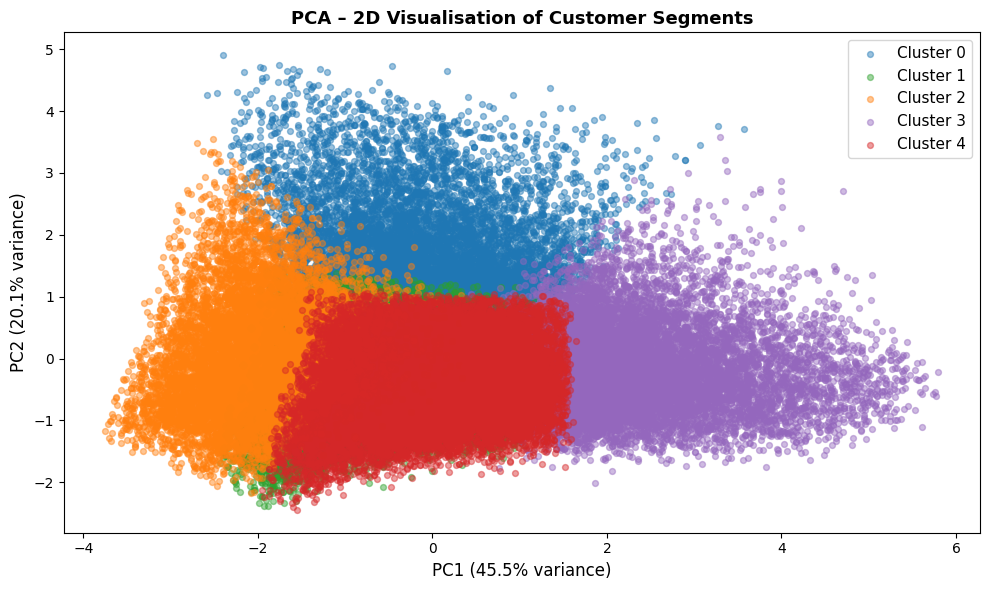

In [66]:
# We already ran PCA for the clustering visuals in the Silhouette method but will redo

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

print(f'Variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.1%}')
print(f'Variance of each PC: {pca.explained_variance_ratio_}')

#Visual of Clusters with PCA

fig, ax = plt.subplots(figsize=(10,6))

colors_c = ['#1f77b4','#2ca02c','#ff7f0e','#9467bd','#d62728']
for c in range(k_optimal):
    x = df_clean['Cluster'] == c
    ax.scatter(df_pca[x,0], df_pca[x,1],
               c = colors_c[c],
               label=f'Cluster {c}',
               alpha=0.45,
               s=18)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('PCA – 2D Visualisation of Customer Segments',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('pca.png')
plt.show()

**Observations**

- PCA explains 65.6% of the variance which is relatively low

- There are many overlapping data points, and some inter-cluster blending is visible. Cluster 4 almost entirely overlaps with other clusters.

— This is a consequence of PCA being a linear technique that cannot fully capture non-linear cluster boundaries.

#### 7.2 t-SNE

t-SNE is applied to a random sample of 5,000 customers using perplexity=40. Cluster labels from K-Means are used to colour the points.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


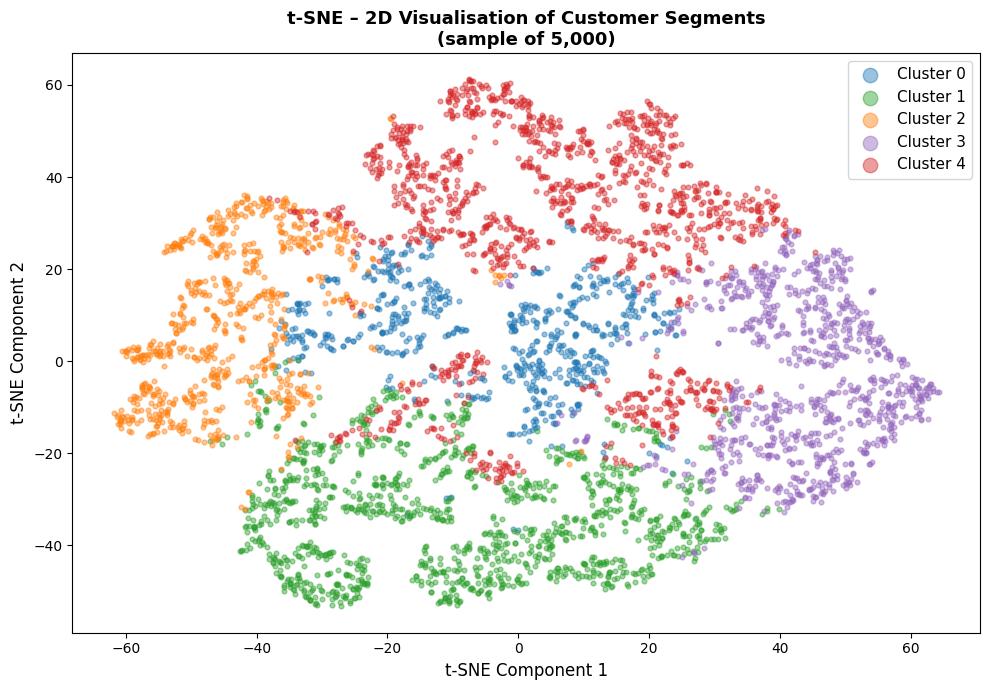

In [67]:
#tsne sample

TSNE_SAMPLE = 5000
np.random.seed(42)
tsne_idx    = np.random.choice(len(df_scaled), TSNE_SAMPLE, replace=False)
X_tsne_in   = df_scaled[tsne_idx]
tsne_labels = df_clean['Cluster'].values[tsne_idx]

#Run tsne

tsne   = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_tsne_in)

#Create Visual

fig, ax = plt.subplots(figsize=(10, 7))
for c in range(k_optimal):
    m = tsne_labels == c
    ax.scatter(X_tsne[m, 0], X_tsne[m, 1],
               c=colors_c[c], alpha=0.45, s=12, label=f'Cluster {c}')
ax.set_xlabel('t-SNE Component 1', fontsize=12)
ax.set_ylabel('t-SNE Component 2', fontsize=12)
ax.set_title(f't-SNE – 2D Visualisation of Customer Segments\n(sample of {TSNE_SAMPLE:,})',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, markerscale=3)
plt.tight_layout()
plt.savefig('tsne.png')
plt.show()

**Observations**

- t-SNE produces much clearer visual of the clusters than PCA. t-SNE is a more effective tool for visualising segment distinctiveness and improves interpretability.
- Visual shows clear clustering for clusters 1,2 and 3
- Some overlapping between clusters 0 and 4
- The visual validates the choice to pick k=5, with 5 clear clusters shown.


## 8. Conclusions

**Project Summary**



- K-Means clustering with k=5 identified five distinct customer segments across 66,796 customers (after removal of 1,504 outliers). Segments were derived from five behavioural and demographic features: Purchase Frequency, Recency (inverted), Customer Lifetime Value, Average Unit Cost, and Age. StandardScaler was applied prior to clustering to ensure no single feature dominated due to scale differences.

- The five segments represent meaningfully different customer profiles, ranging from a small high-value active group contributing disproportionate revenue, to a lapsed low-engagement group requiring re-activation strategies. Notably, age emerged as a differentiating factor between two mid-value segments, separating younger regulars (mean age 37) from older regulars (mean age 69) — a distinction that has direct implications for marketing channel and
communication strategy.

- t-SNE visualisation confirmed reasonable cluster separation in reduced dimensional space, with the high-value (Cluster 3) and lapsed (Cluster 2) segments showing the strongest distinctiveness. Some overlap between mid-value clusters (0, 1, 4) is expected, given the modest silhouette scores observed throughout the analysis, reflecting the inherently
continuous nature of customer behavioural data.

In [68]:
#create a database to effectively show 5 clusters and given names

cluster_summary = pd.DataFrame({
    'Cluster': [0, 1, 2, 3, 4],
    'Segment Name': [
        'Premium Buyers',
        'Older Regulars',
        'Lapsed Customers',
        'High Value Active',
        'Young Regulars'
    ],
    'Size': [8386, 17340, 9587, 12801, 18682],
    'Size (%)': ['12.6%', '26.0%', '14.4%', '19.2%', '28.0%'],
    'Avg Frequency': [8.1, 10.7, 4.8, 30.0, 12.2],
    'Avg Recency (inverted)': [1386, 1598, 690, 1696, 1594],
    'Avg CLV (£)': [1782, 1276, 550, 4387, 1481],
    'Avg Unit Cost (£)': [128.7, 65.6, 59.5, 81.9, 67.5],
    'Avg Age': [52, 69, 57, 48, 37],
    'Key Characteristic': [
        'High spend per item, moderate engagement',
        'Long-term older customers, moderate value',
        'Low frequency, low recency, disengaged',
        'Most frequent, most recent, highest CLV',
        'Youngest segment, moderate and growing value'
    ]
})

cluster_summary.set_index('Cluster', inplace=True)
cluster_summary.style.set_caption('Customer Segment Profiles — K-Means k=5') \
    .set_properties(**{'text-align': 'left'}) \
    .highlight_max(subset=['Avg Frequency', 'Avg CLV (£)', 'Avg Unit Cost (£)'], color='lightgreen') \
    .highlight_min(subset=['Avg Frequency', 'Avg CLV (£)'], color='lightsalmon')

,Segment Name,Size,Size (%),Avg Frequency,Avg Recency (inverted),Avg CLV (£),Avg Unit Cost (£),Avg Age,Key Characteristic
Cluster,,,,,,,,,
0,Premium Buyers,8386,12.6%,8.100000,1386,1782,128.700000,52,"High spend per item, moderate engagement"
1,Older Regulars,17340,26.0%,10.700000,1598,1276,65.600000,69,"Long-term older customers, moderate value"
2,Lapsed Customers,9587,14.4%,4.800000,690,550,59.500000,57,"Low frequency, low recency, disengaged"
3,High Value Active,12801,19.2%,30.000000,1696,4387,81.900000,48,"Most frequent, most recent, highest CLV"
4,Young Regulars,18682,28.0%,12.200000,1594,1481,67.500000,37,"Youngest segment, moderate and growing value"


**Customer Segment Profiles — Key Findings**

- Cluster 3 (High Value Active) is the most commercially valuable segment despite representing only 19.2% of customers, contributing the highest average CLV of £4,387 and purchasing nearly three times more frequently than the average customer.

- Cluster 2 (Lapsed Customers) is the most at-risk segment, characterised by the lowest recency score (690), lowest frequency (4.8), and lowest CLV (£550) — representing 14.4% of the customer base and a clear target for re-engagement campaigns.

- Cluster 0 (Premium Buyers) is distinguished primarily by its significantly higher average unit cost (£128.70 vs £60–82 across all other clusters), suggesting a smaller niche of customers purchasing higher-end products despite moderate purchase frequency.

- Cluster 1 (Old Regulars) and Cluster 4 (Young Regulars) represent the largest share of the customer base combined (54%), differing most notably in age (69 vs 37) despite similar frequency and CLV — suggesting Age-targeted marketing strategies would be the primary differentiator between these two groups.